# Gulf NBS Panel — EDA
**Research question**: Do investments in urban nature-based solutions reduce economic vulnerability to extreme heat in Gulf cities?

**Panel**: 20 cities × 24 years (2000–2023) = 480 city-year observations

In [1]:
import warnings, os
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
import seaborn as sns
from scipy import stats

matplotlib.rcParams['figure.dpi'] = 130
matplotlib.rcParams['font.size']   = 10
plt.style.use('seaborn-v0_8-whitegrid')

PROC = 'data/processed/'
FIG  = 'outputs/figures/'
os.makedirs(FIG, exist_ok=True)

df = pd.read_csv(PROC + 'master_panel.csv')
print(f'Panel shape: {df.shape}')
print(f'Cities: {sorted(df.city.unique())}')
df.head(3)

Panel shape: (480, 21)
Cities: ['Abu Dhabi', 'Ajman', 'Al Ain', 'Al Mubarraz', 'Buraydah', 'Dammam', 'Doha', 'Dubai', 'Jeddah', 'Khobar', 'Kuwait City', 'Manama', 'Mecca', 'Medina', 'Muscat', 'Ras Al Khaimah', 'Riyadh', 'Sharjah', 'Sohar', 'Taif']


,city,country,year,elec_pc,industry_va,fdi_pct,ntl_calibrated,ntl_log,ntl_source,ntl_raw,...,gdp_pc,city_pop_th,pop_src,urban_pct,oil_price,env_exp_pct_gdp,ndvi_harvard_2010,ndvi_harvard_2015,ndvi_harvard_2020,ndvi_harvard_2021
0,Abu Dhabi,ARE,2000,10724.544342,48.517012,-0.485282,6.204863,1.974756,DMSP_calibrated,27.300139,...,56939.270181,273.702,UN WUP 2025,79.287092,28.845275,NaN,NaN,NaN,NaN,NaN
1,Abu Dhabi,ARE,2001,10875.257480,49.676341,1.145892,6.990133,2.078207,DMSP_calibrated,27.820713,...,54169.415353,295.447,UN WUP 2025,79.746900,24.713763,NaN,NaN,NaN,NaN,NaN
2,Abu Dhabi,ARE,2002,11107.387588,47.545748,0.086781,7.510005,2.141243,DMSP_calibrated,28.165348,...,52216.875322,317.193,UN WUP 2025,80.270560,25.115096,NaN,NaN,NaN,NaN,NaN


In [2]:

# ── Colour palette (consistent across all figures) ────────────────────────────
COUNTRY_COLORS = {
    'KWT': '#534AB7',
    'QAT': '#1D9E75',
    'ARE': '#D85A30',
    'SAU': '#C8A02C',
    'OMN': '#2D7DA8',
    'BHR': '#8E3D7A',
}
COUNTRY_LABELS = {
    'KWT': 'Kuwait', 'QAT': 'Qatar', 'ARE': 'UAE',
    'SAU': 'Saudi Arabia', 'OMN': 'Oman', 'BHR': 'Bahrain',
}

CITY_ISO3 = df.drop_duplicates('city').set_index('city')['country'].to_dict()

def city_color(city):
    return COUNTRY_COLORS[CITY_ISO3[city]]

def country_legend(ax, loc='upper left'):
    patches = [mpatches.Patch(color=c, label=COUNTRY_LABELS[k])
               for k, c in COUNTRY_COLORS.items()]
    ax.legend(handles=patches, loc=loc, fontsize=8, framealpha=0.8)

def savefig(name):
    plt.tight_layout()
    plt.savefig(FIG + name, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {FIG}{name}')

NUMERIC_COLS = ['ndvi','ntl_calibrated','ntl_log','elec_pc','industry_va',
                'fdi_pct','gdp_pc','city_pop_th','urban_pct','oil_price','env_exp_pct_gdp']
print('Palette and helpers ready.')


Palette and helpers ready.


## §1. Data Overview

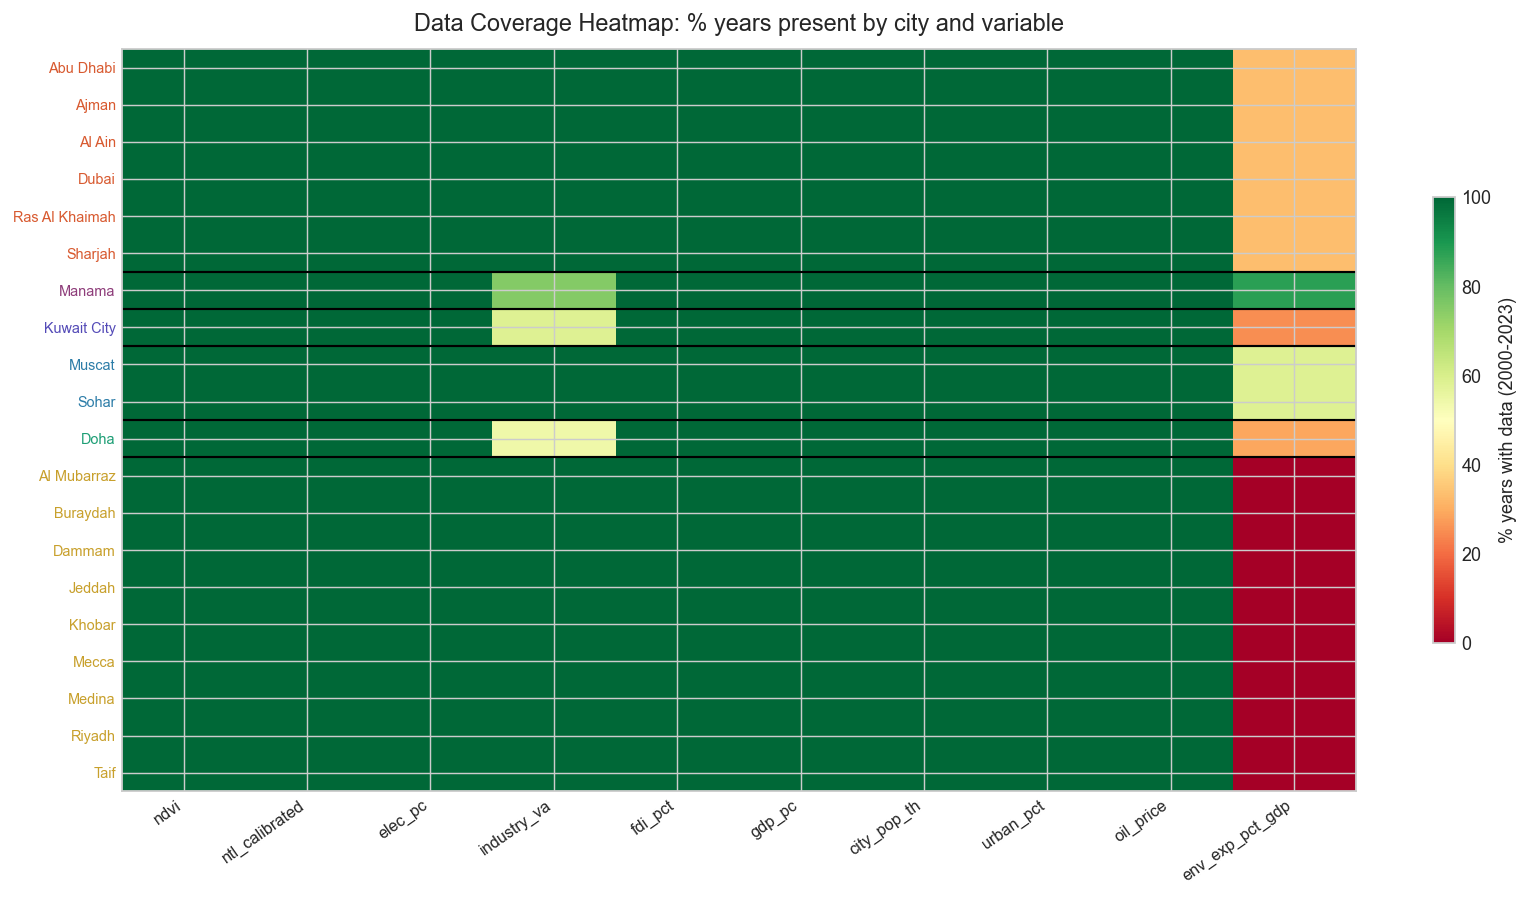

Saved: outputs/figures/s1_coverage_heatmap.png


In [3]:

# §1a. Coverage heatmap: variable × city-year
HMAP_COLS = ['ndvi','ntl_calibrated','elec_pc','industry_va','fdi_pct',
             'gdp_pc','city_pop_th','urban_pct','oil_price','env_exp_pct_gdp']

cities_ordered = (df.drop_duplicates('city')
                    .sort_values(['country','city'])['city'].tolist())

# Build presence matrix: rows = city, cols = variable, values = % years present
presence = pd.DataFrame(index=cities_ordered, columns=HMAP_COLS, dtype=float)
for city in cities_ordered:
    cdf = df[df['city'] == city]
    for col in HMAP_COLS:
        presence.loc[city, col] = cdf[col].notna().mean() * 100

fig, ax = plt.subplots(figsize=(13, 7))
im = ax.imshow(presence.values.astype(float), aspect='auto',
               cmap='RdYlGn', vmin=0, vmax=100)
ax.set_xticks(range(len(HMAP_COLS)))
ax.set_xticklabels(HMAP_COLS, rotation=35, ha='right', fontsize=9)
ax.set_yticks(range(len(cities_ordered)))
ax.set_yticklabels(cities_ordered, fontsize=8)

# Country border lines
country_breaks = []
prev = None
for i, city in enumerate(cities_ordered):
    c = CITY_ISO3[city]
    if c != prev:
        if prev is not None:
            country_breaks.append(i - 0.5)
        prev = c
for y in country_breaks:
    ax.axhline(y=y, color='black', linewidth=1.2)

# Color country labels on y-axis
for i, city in enumerate(cities_ordered):
    ax.get_yticklabels()[i].set_color(COUNTRY_COLORS[CITY_ISO3[city]])

plt.colorbar(im, ax=ax, label='% years with data (2000-2023)', shrink=0.6)
ax.set_title('Data Coverage Heatmap: % years present by city and variable', fontsize=13, pad=10)
savefig('s1_coverage_heatmap.png')


In [4]:

# §1b. Missing values table
miss_tbl = pd.DataFrame({
    'Variable': HMAP_COLS,
    'N_present': [df[c].notna().sum() for c in HMAP_COLS],
    'N_missing': [df[c].isna().sum() for c in HMAP_COLS],
    'Pct_complete': [f"{df[c].notna().mean()*100:.1f}%" for c in HMAP_COLS],
    'Note': [
        'GEE annual mean, all cities/years', 'DMSP+VIIRS calibrated', 'kWh/capita WDI',
        'BHR 2000-05, KWT 2000-09, QAT 2000-10 missing',
        'WDI complete', 'constant 2015 USD WDI',
        'city-level from UN WUP / citypopulation.de', '% WDI',
        'Annual mean Brent crude', 'IMF – SAU absent, others partial'
    ]
})
display(miss_tbl)


,Variable,N_present,N_missing,Pct_complete,Note
0,ndvi,480,0,100.0%,"GEE annual mean, all cities/years"
1,ntl_calibrated,480,0,100.0%,DMSP+VIIRS calibrated
2,elec_pc,480,0,100.0%,kWh/capita WDI
3,industry_va,453,27,94.4%,"BHR 2000-05, KWT 2000-09, QAT 2000-10 missing"
4,fdi_pct,480,0,100.0%,WDI complete
5,gdp_pc,480,0,100.0%,constant 2015 USD WDI
6,city_pop_th,480,0,100.0%,city-level from UN WUP / citypopulation.de
7,urban_pct,480,0,100.0%,% WDI
8,oil_price,480,0,100.0%,Annual mean Brent crude
9,env_exp_pct_gdp,110,370,22.9%,"IMF – SAU absent, others partial"


In [5]:

# §1c. Summary statistics by country
stat_cols = ['ndvi','ntl_log','elec_pc','industry_va','fdi_pct','gdp_pc','city_pop_th']
rows = []
for iso, grp in df.groupby('country'):
    for col in stat_cols:
        s = grp[col].dropna()
        if len(s) == 0:
            continue
        rows.append({'Country': COUNTRY_LABELS[iso], 'Variable': col,
                     'Mean': s.mean(), 'SD': s.std(), 'Min': s.min(),
                     'Max': s.max(), 'N': len(s)})
sumstats = pd.DataFrame(rows)
display(sumstats.pivot_table(index='Variable', columns='Country',
                              values='Mean', aggfunc='mean').round(3))


Country,Bahrain,Kuwait,Oman,Qatar,Saudi Arabia,UAE
Variable,,,,,,
city_pop_th,1064.669,2679.044,285.456,1204.216,1429.644,1023.715
elec_pc,20299.488,16300.632,5864.211,16451.706,9616.592,12947.015
fdi_pct,4.943,0.382,3.119,1.781,0.813,3.212
gdp_pc,23885.204,32048.921,19640.063,64238.123,22764.680,47104.846
industry_va,43.767,62.258,56.813,62.338,53.495,49.299
ndvi,0.084,0.076,0.094,0.068,0.095,0.110
ntl_log,3.213,3.371,1.005,3.779,3.358,2.986


## §2. NDVI Exploration (Primary IV)

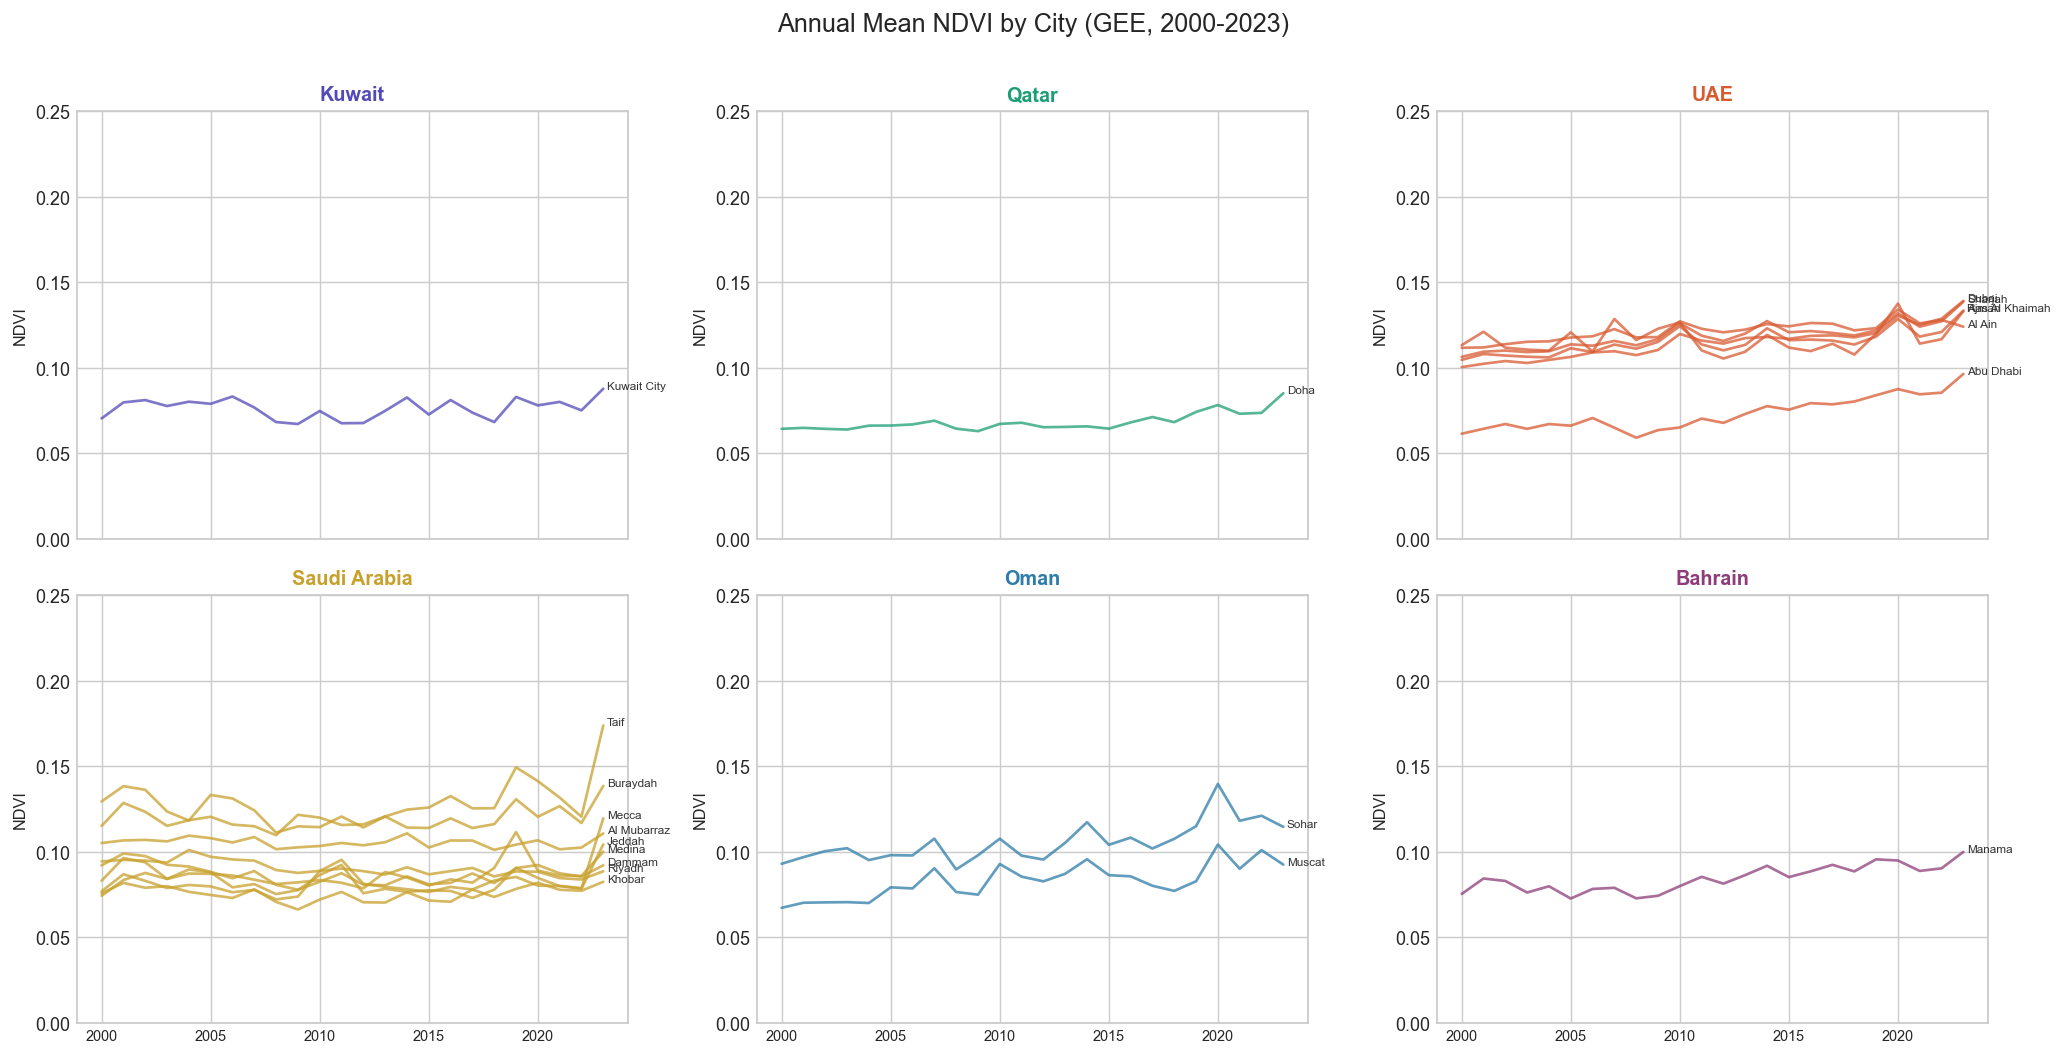

Saved: outputs/figures/s2a_ndvi_timeseries.png


In [6]:

# §2a. NDVI time series faceted by country (6 panels)
countries = ['KWT','QAT','ARE','SAU','OMN','BHR']
fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=True)
axes = axes.flatten()

for ax, iso in zip(axes, countries):
    cities_in = df[df['country']==iso]['city'].unique()
    for city in sorted(cities_in):
        cdf = df[df['city']==city].sort_values('year')
        ax.plot(cdf['year'], cdf['ndvi'], linewidth=1.5,
                color=COUNTRY_COLORS[iso], alpha=0.75)
        last = cdf.iloc[-1]
        ax.annotate(city, (last['year'], last['ndvi']),
                    fontsize=6.5, xytext=(2,0),
                    textcoords='offset points', color='#333')
    ax.set_title(COUNTRY_LABELS[iso], fontsize=11,
                 color=COUNTRY_COLORS[iso], fontweight='bold')
    ax.set_ylabel('NDVI', fontsize=9)
    ax.xaxis.set_major_locator(mticker.MultipleLocator(5))
    ax.tick_params(axis='x', labelsize=8)
    ax.set_ylim(0, 0.25)

fig.suptitle('Annual Mean NDVI by City (GEE, 2000-2023)', fontsize=14, y=1.01)
savefig('s2a_ndvi_timeseries.png')


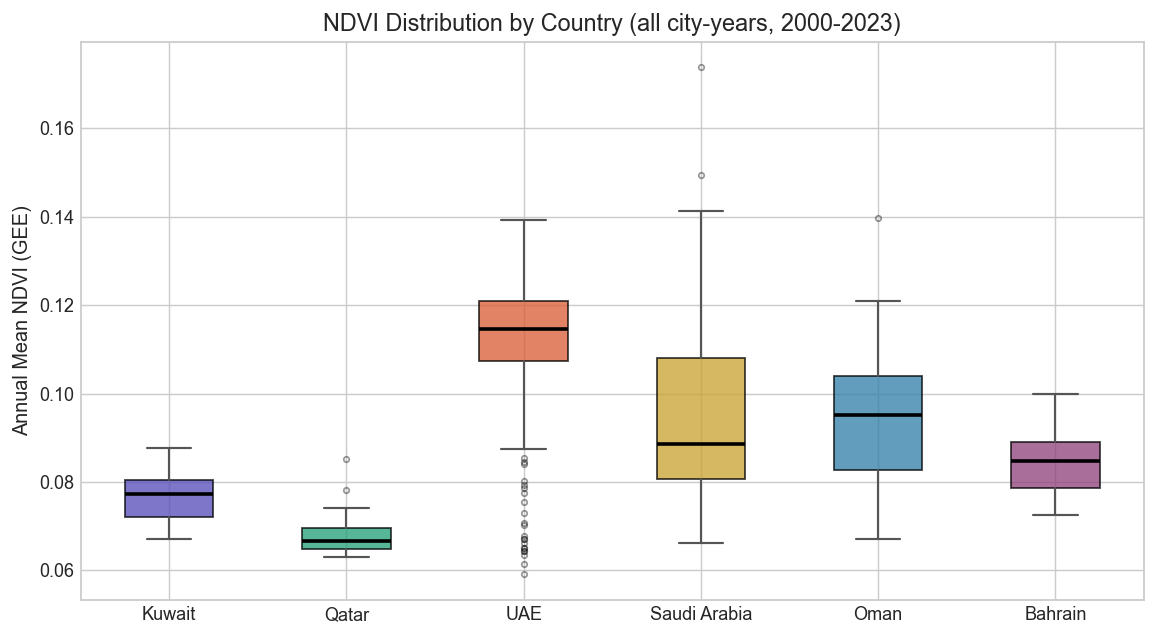

Saved: outputs/figures/s2b_ndvi_boxplot.png


In [7]:

# §2b. NDVI boxplot by country
fig, ax = plt.subplots(figsize=(9, 5))
order = ['KWT','QAT','ARE','SAU','OMN','BHR']
data_by_country = [df[df['country']==iso]['ndvi'].dropna().values for iso in order]
bp = ax.boxplot(data_by_country, patch_artist=True, notch=False,
                medianprops=dict(color='black', linewidth=2))
for patch, iso in zip(bp['boxes'], order):
    patch.set_facecolor(COUNTRY_COLORS[iso])
    patch.set_alpha(0.75)
for whisker in bp['whiskers']:
    whisker.set(linewidth=1.2, color='#555')
for cap in bp['caps']:
    cap.set(linewidth=1.2, color='#555')
for flier in bp['fliers']:
    flier.set(marker='o', markersize=3, alpha=0.4)

ax.set_xticks(range(1, len(order)+1))
ax.set_xticklabels([COUNTRY_LABELS[iso] for iso in order], fontsize=10)
ax.set_ylabel('Annual Mean NDVI (GEE)', fontsize=11)
ax.set_title('NDVI Distribution by Country (all city-years, 2000-2023)', fontsize=13)
savefig('s2b_ndvi_boxplot.png')


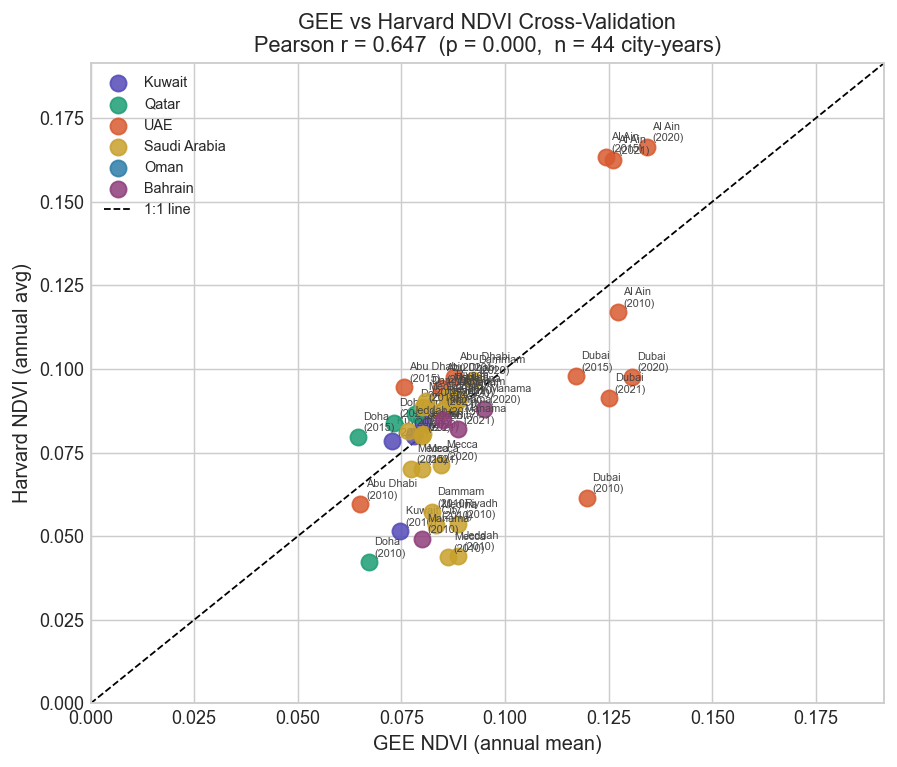

Saved: outputs/figures/s2c_ndvi_crossvalidation.png
Cross-validation: r = 0.647, p = 0.0000, n = 44


In [8]:

# §2c. GEE vs Harvard NDVI cross-validation (11 cities × 4 years)
harv_yrs = [2010, 2015, 2020, 2021]
xval = []
for yr in harv_yrs:
    col = f'ndvi_harvard_{yr}'
    sub = df[(df['year'] == yr) & df[col].notna()][['city','country','ndvi', col]].copy()
    sub['harvard_yr'] = yr
    sub = sub.rename(columns={col: 'ndvi_harvard'})
    xval.append(sub)
xval = pd.concat(xval, ignore_index=True)

r, pval = stats.pearsonr(xval['ndvi'], xval['ndvi_harvard'])

fig, ax = plt.subplots(figsize=(7, 6))
for iso in order:
    s = xval[xval['country']==iso]
    ax.scatter(s['ndvi'], s['ndvi_harvard'],
               color=COUNTRY_COLORS[iso], s=80, zorder=3,
               label=COUNTRY_LABELS[iso], alpha=0.85)
    for _, row in s.iterrows():
        ax.annotate(f"{row['city']}\n({row['harvard_yr']})",
                    (row['ndvi'], row['ndvi_harvard']),
                    fontsize=6, xytext=(3,3), textcoords='offset points', color='#444')

lim = [0, max(xval['ndvi'].max(), xval['ndvi_harvard'].max()) * 1.15]
ax.plot(lim, lim, 'k--', linewidth=1, label='1:1 line', zorder=1)
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel('GEE NDVI (annual mean)', fontsize=11)
ax.set_ylabel('Harvard NDVI (annual avg)', fontsize=11)
ax.set_title(f'GEE vs Harvard NDVI Cross-Validation\nPearson r = {r:.3f}  (p = {pval:.3f},  n = {len(xval)} city-years)',
             fontsize=12)
ax.legend(fontsize=8, loc='upper left')
savefig('s2c_ndvi_crossvalidation.png')
print(f'Cross-validation: r = {r:.3f}, p = {pval:.4f}, n = {len(xval)}')


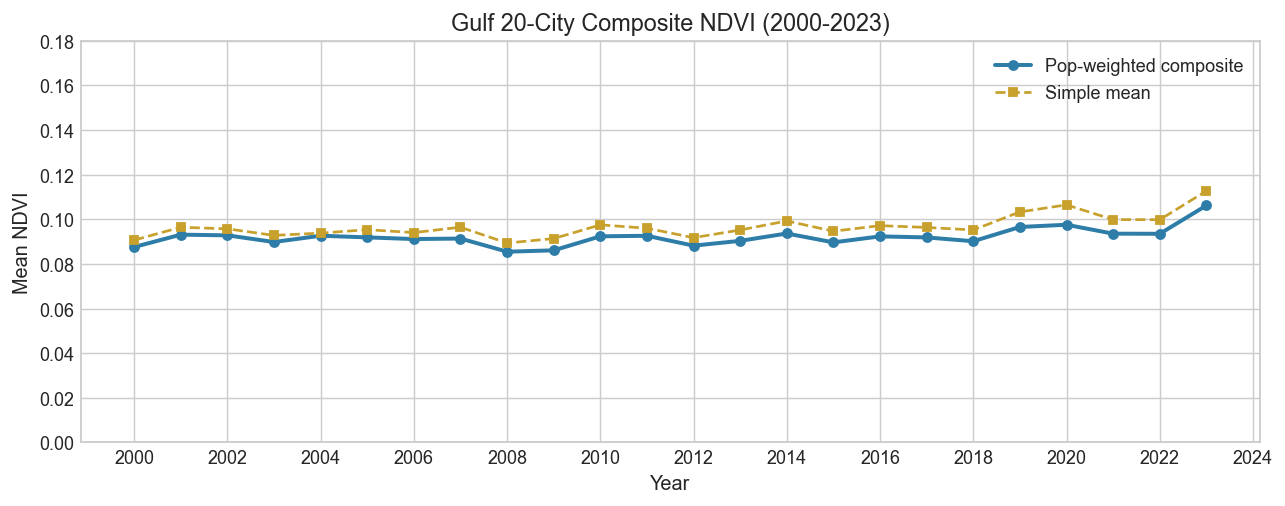

Saved: outputs/figures/s2d_ndvi_composite.png


In [9]:

# §2d. Population-weighted Gulf composite NDVI 2000-2023
pw = df.groupby('year').apply(
    lambda g: np.average(g['ndvi'], weights=g['city_pop_th'])
).reset_index(name='ndvi_pop_weighted')
unw = df.groupby('year')['ndvi'].mean().reset_index(name='ndvi_unweighted')
comp = pw.merge(unw, on='year')

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(comp['year'], comp['ndvi_pop_weighted'], 'o-', color='#2D7DA8',
        linewidth=2.2, markersize=5, label='Pop-weighted composite')
ax.plot(comp['year'], comp['ndvi_unweighted'], 's--', color='#C8A02C',
        linewidth=1.5, markersize=4, label='Simple mean')
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Mean NDVI', fontsize=11)
ax.set_title('Gulf 20-City Composite NDVI (2000-2023)', fontsize=13)
ax.legend(fontsize=10)
ax.xaxis.set_major_locator(mticker.MultipleLocator(2))
ax.set_ylim(0, 0.18)
savefig('s2d_ndvi_composite.png')


## §3. NTL Exploration

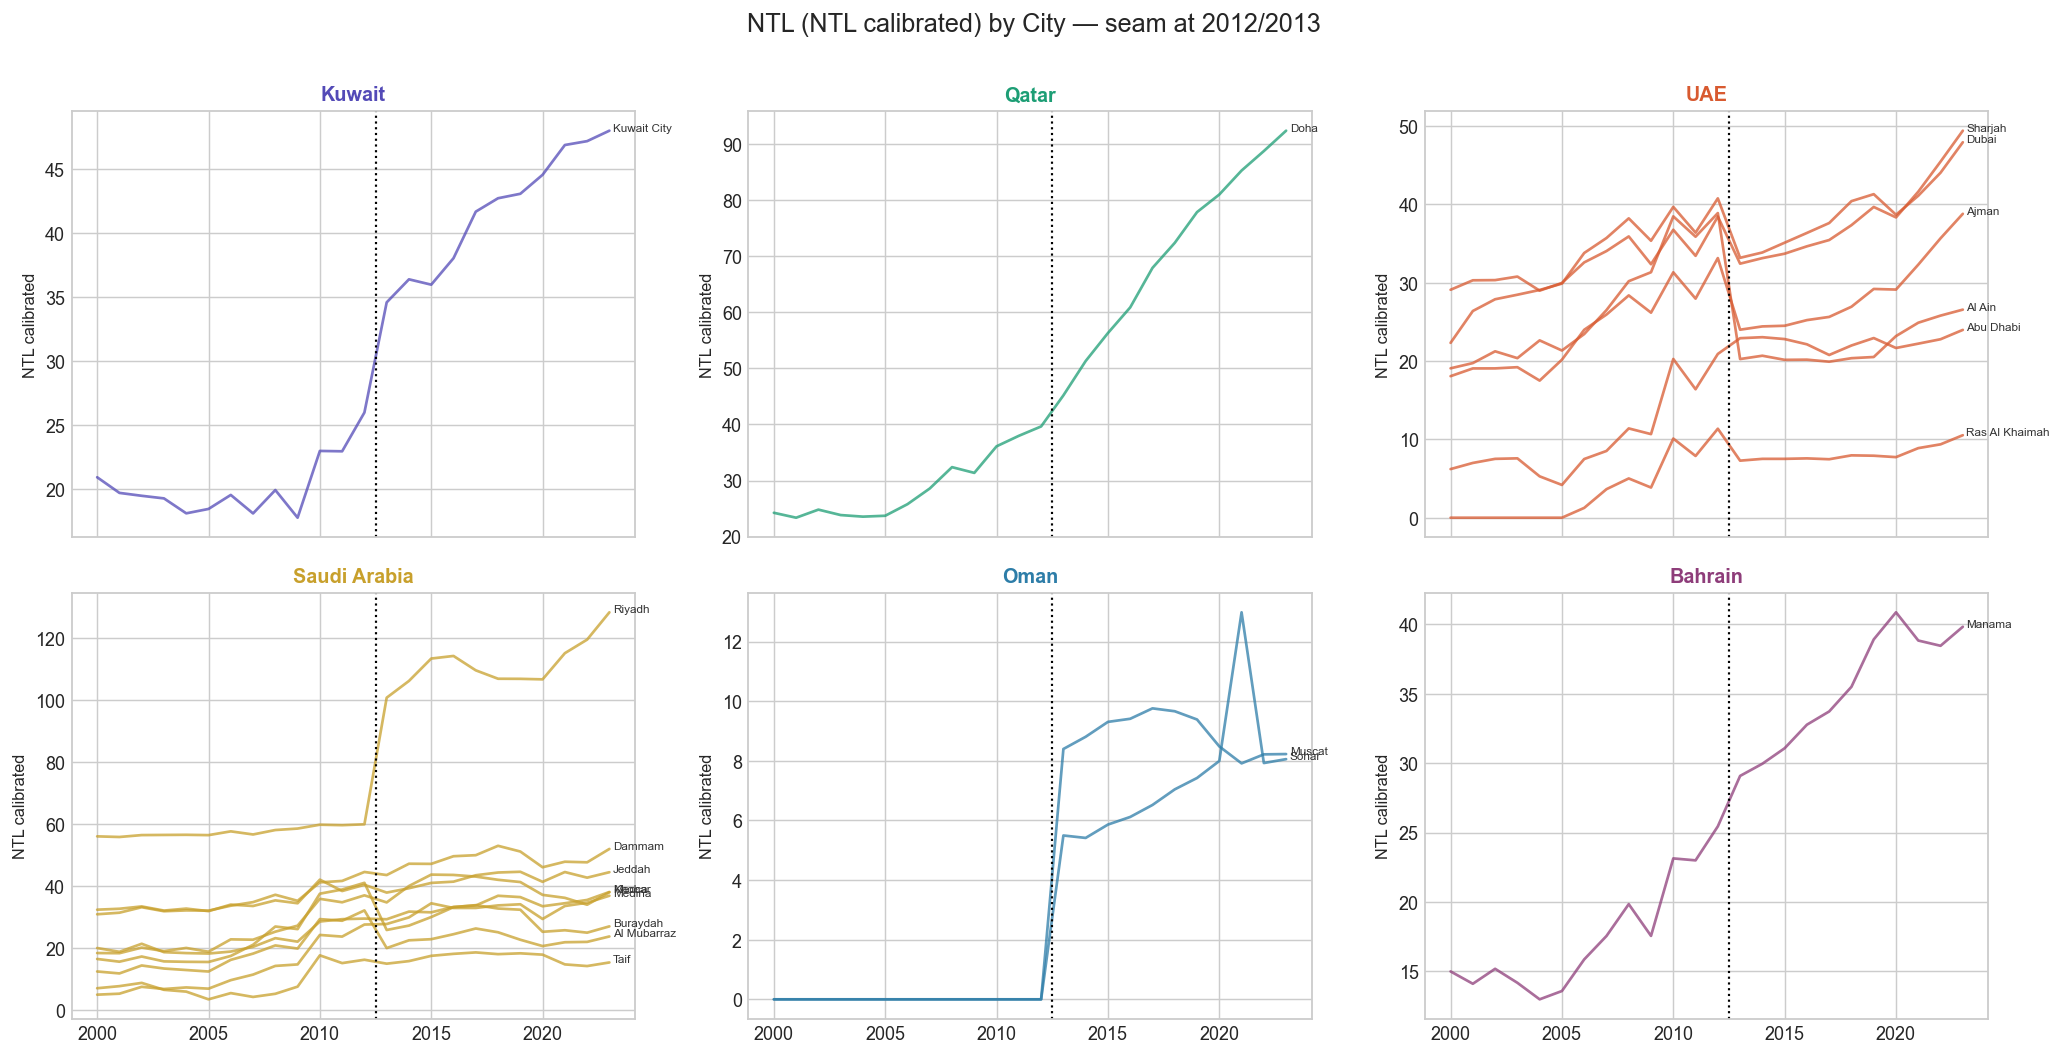

Saved: outputs/figures/s3a_ntl_levels.png


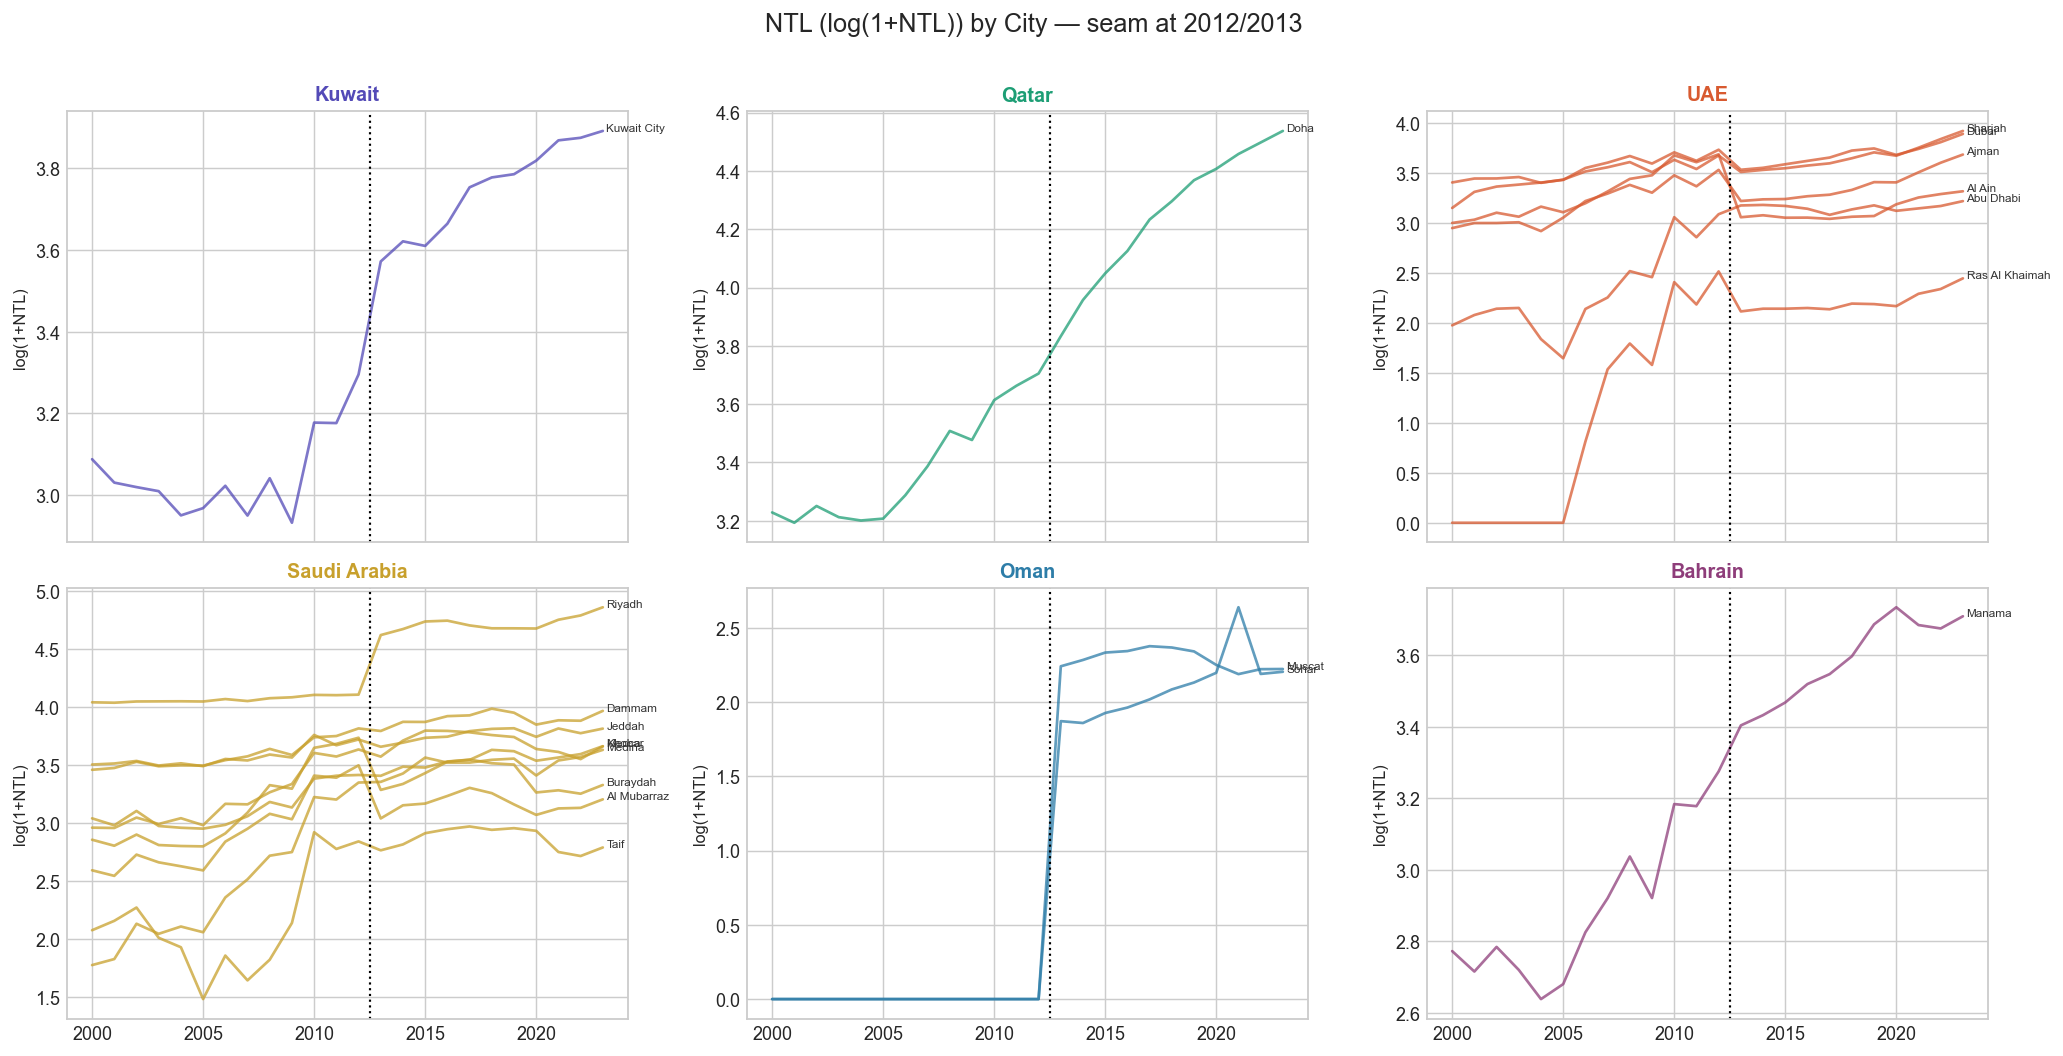

Saved: outputs/figures/s3b_ntl_log.png


In [10]:

# §3a & 3b. NTL time series: levels and log — 2 rows, 6 cols (one panel per country)
for var, ylabel, filetag in [
    ('ntl_calibrated', 'NTL calibrated', 's3a_ntl_levels'),
    ('ntl_log',        'log(1+NTL)',      's3b_ntl_log'),
]:
    fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=True)
    axes = axes.flatten()
    for ax, iso in zip(axes, countries):
        cities_in = sorted(df[df['country']==iso]['city'].unique())
        for city in cities_in:
            cdf = df[df['city']==city].sort_values('year')
            ax.plot(cdf['year'], cdf[var], linewidth=1.5,
                    color=COUNTRY_COLORS[iso], alpha=0.75)
            ax.annotate(city, (cdf['year'].iloc[-1], cdf[var].iloc[-1]),
                        fontsize=6.5, xytext=(2,0),
                        textcoords='offset points', color='#333')
        ax.axvline(2012.5, color='black', linestyle=':', linewidth=1.2, label='2012/13 seam')
        ax.set_title(COUNTRY_LABELS[iso], fontsize=11,
                     color=COUNTRY_COLORS[iso], fontweight='bold')
        ax.set_ylabel(ylabel, fontsize=9)
        ax.xaxis.set_major_locator(mticker.MultipleLocator(5))
    fig.suptitle(f'NTL ({ylabel}) by City — seam at 2012/2013', fontsize=14, y=1.01)
    savefig(f'{filetag}.png')


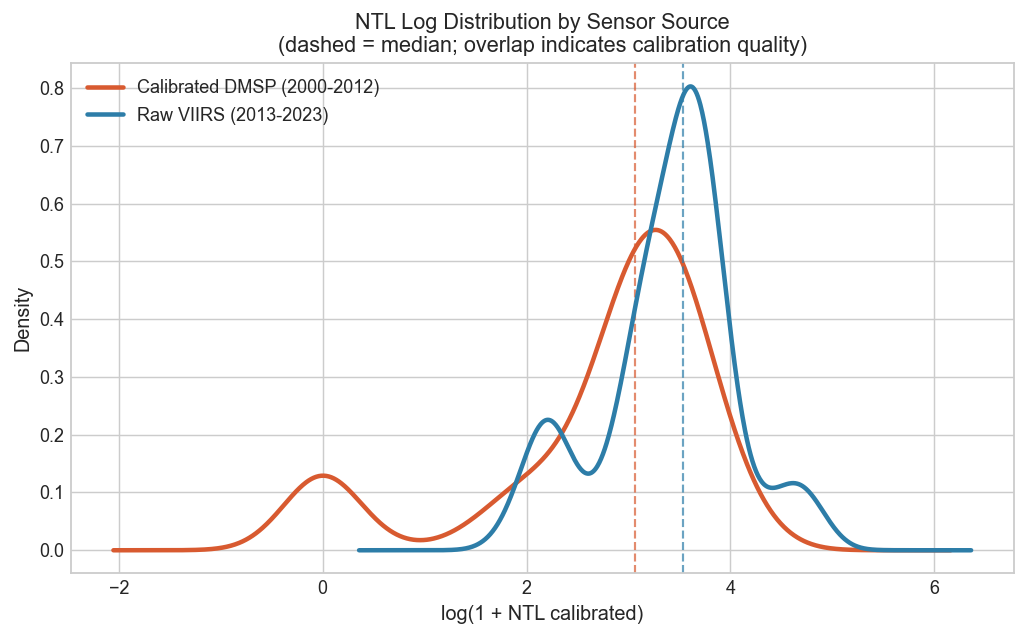

Saved: outputs/figures/s3c_ntl_kde_by_source.png


In [11]:

# §3c. KDE of ntl_log by sensor source
fig, ax = plt.subplots(figsize=(8, 5))
for source, color, label in [
    ('DMSP_calibrated', '#D85A30', 'Calibrated DMSP (2000-2012)'),
    ('VIIRS',           '#2D7DA8', 'Raw VIIRS (2013-2023)'),
]:
    vals = df[df['ntl_source']==source]['ntl_log'].dropna()
    vals.plot.kde(ax=ax, color=color, linewidth=2.5, label=label)
    ax.axvline(vals.median(), color=color, linestyle='--', linewidth=1.2, alpha=0.7)

ax.set_xlabel('log(1 + NTL calibrated)', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title('NTL Log Distribution by Sensor Source\n(dashed = median; overlap indicates calibration quality)',
             fontsize=12)
ax.legend(fontsize=10)
savefig('s3c_ntl_kde_by_source.png')


## §4. Economic Outcomes Over Time

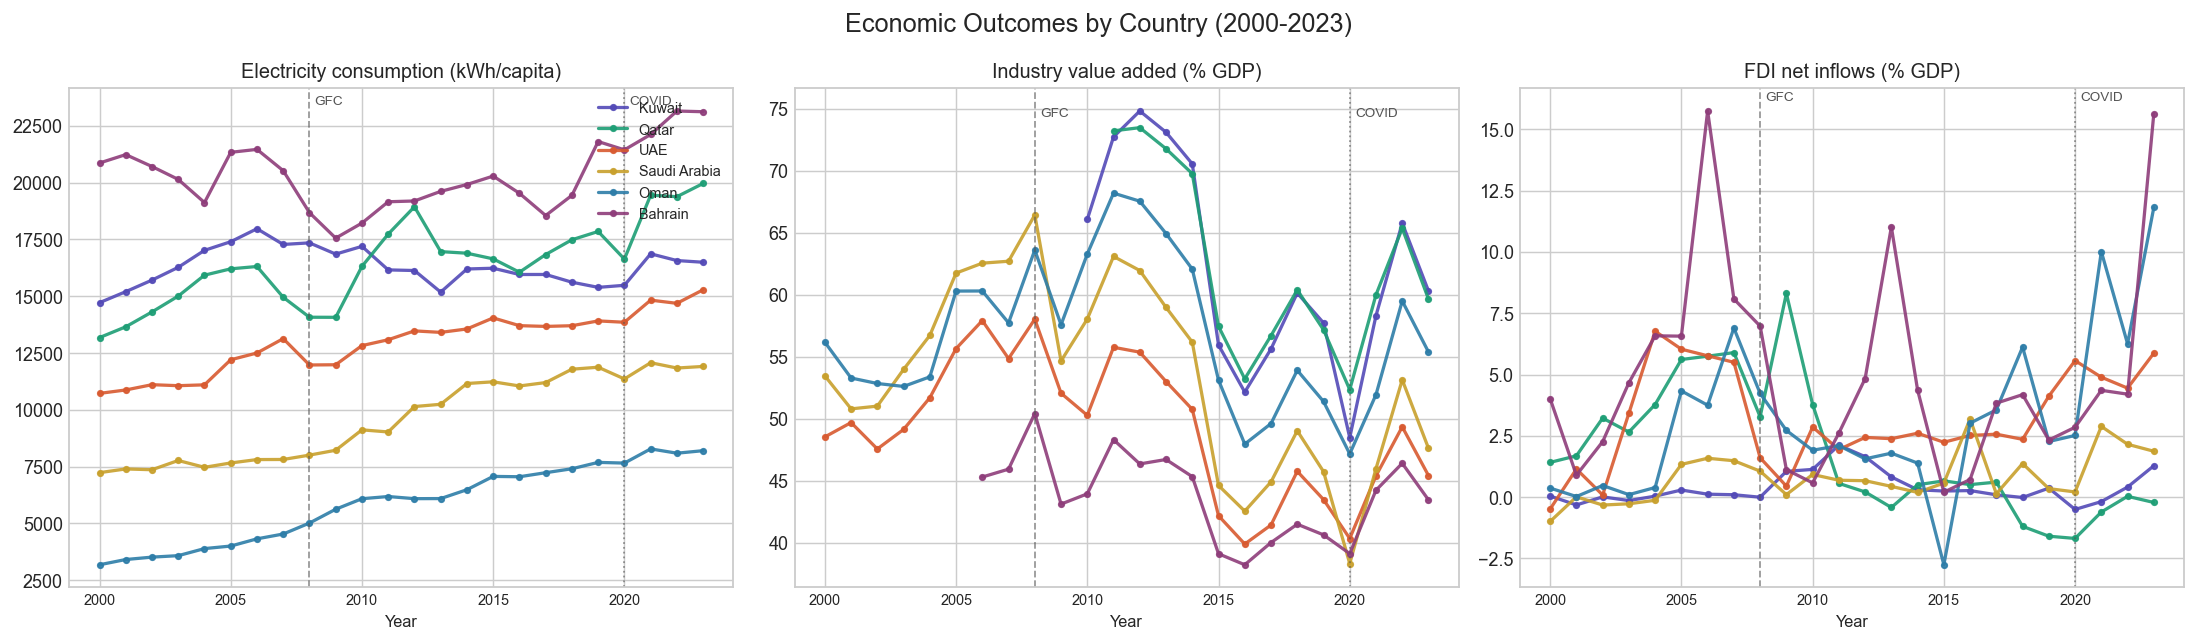

Saved: outputs/figures/s4_economic_outcomes.png


In [12]:

# §4. Country-level economic outcomes: elec_pc, industry_va, fdi_pct
econ_vars = [
    ('elec_pc',     'Electricity consumption (kWh/capita)'),
    ('industry_va', 'Industry value added (% GDP)'),
    ('fdi_pct',     'FDI net inflows (% GDP)'),
]
# Use country-year means (all cities in same country share the value, so just take unique)
ctry_panel = (df.drop_duplicates(['country','year'])
                .sort_values(['country','year']))

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, (var, label) in zip(axes, econ_vars):
    for iso in order:
        sub = ctry_panel[ctry_panel['country']==iso]
        ax.plot(sub['year'], sub[var], '-o', markersize=3,
                color=COUNTRY_COLORS[iso], linewidth=1.8,
                label=COUNTRY_LABELS[iso], alpha=0.9)
    ax.axvline(2008, color='#555', linestyle='--', linewidth=1, alpha=0.6)
    ax.axvline(2020, color='#555', linestyle=':',  linewidth=1, alpha=0.6)
    ax.text(2008.2, ax.get_ylim()[1]*0.97, 'GFC', fontsize=7.5, color='#555')
    ax.text(2020.2, ax.get_ylim()[1]*0.97, 'COVID', fontsize=7.5, color='#555')
    ax.set_title(label, fontsize=11)
    ax.set_xlabel('Year', fontsize=9)
    ax.xaxis.set_major_locator(mticker.MultipleLocator(5))
    ax.tick_params(axis='x', labelsize=8)

axes[0].legend(fontsize=8, loc='upper right')
fig.suptitle('Economic Outcomes by Country (2000-2023)', fontsize=14)
savefig('s4_economic_outcomes.png')


## §5. Pairwise Relationships

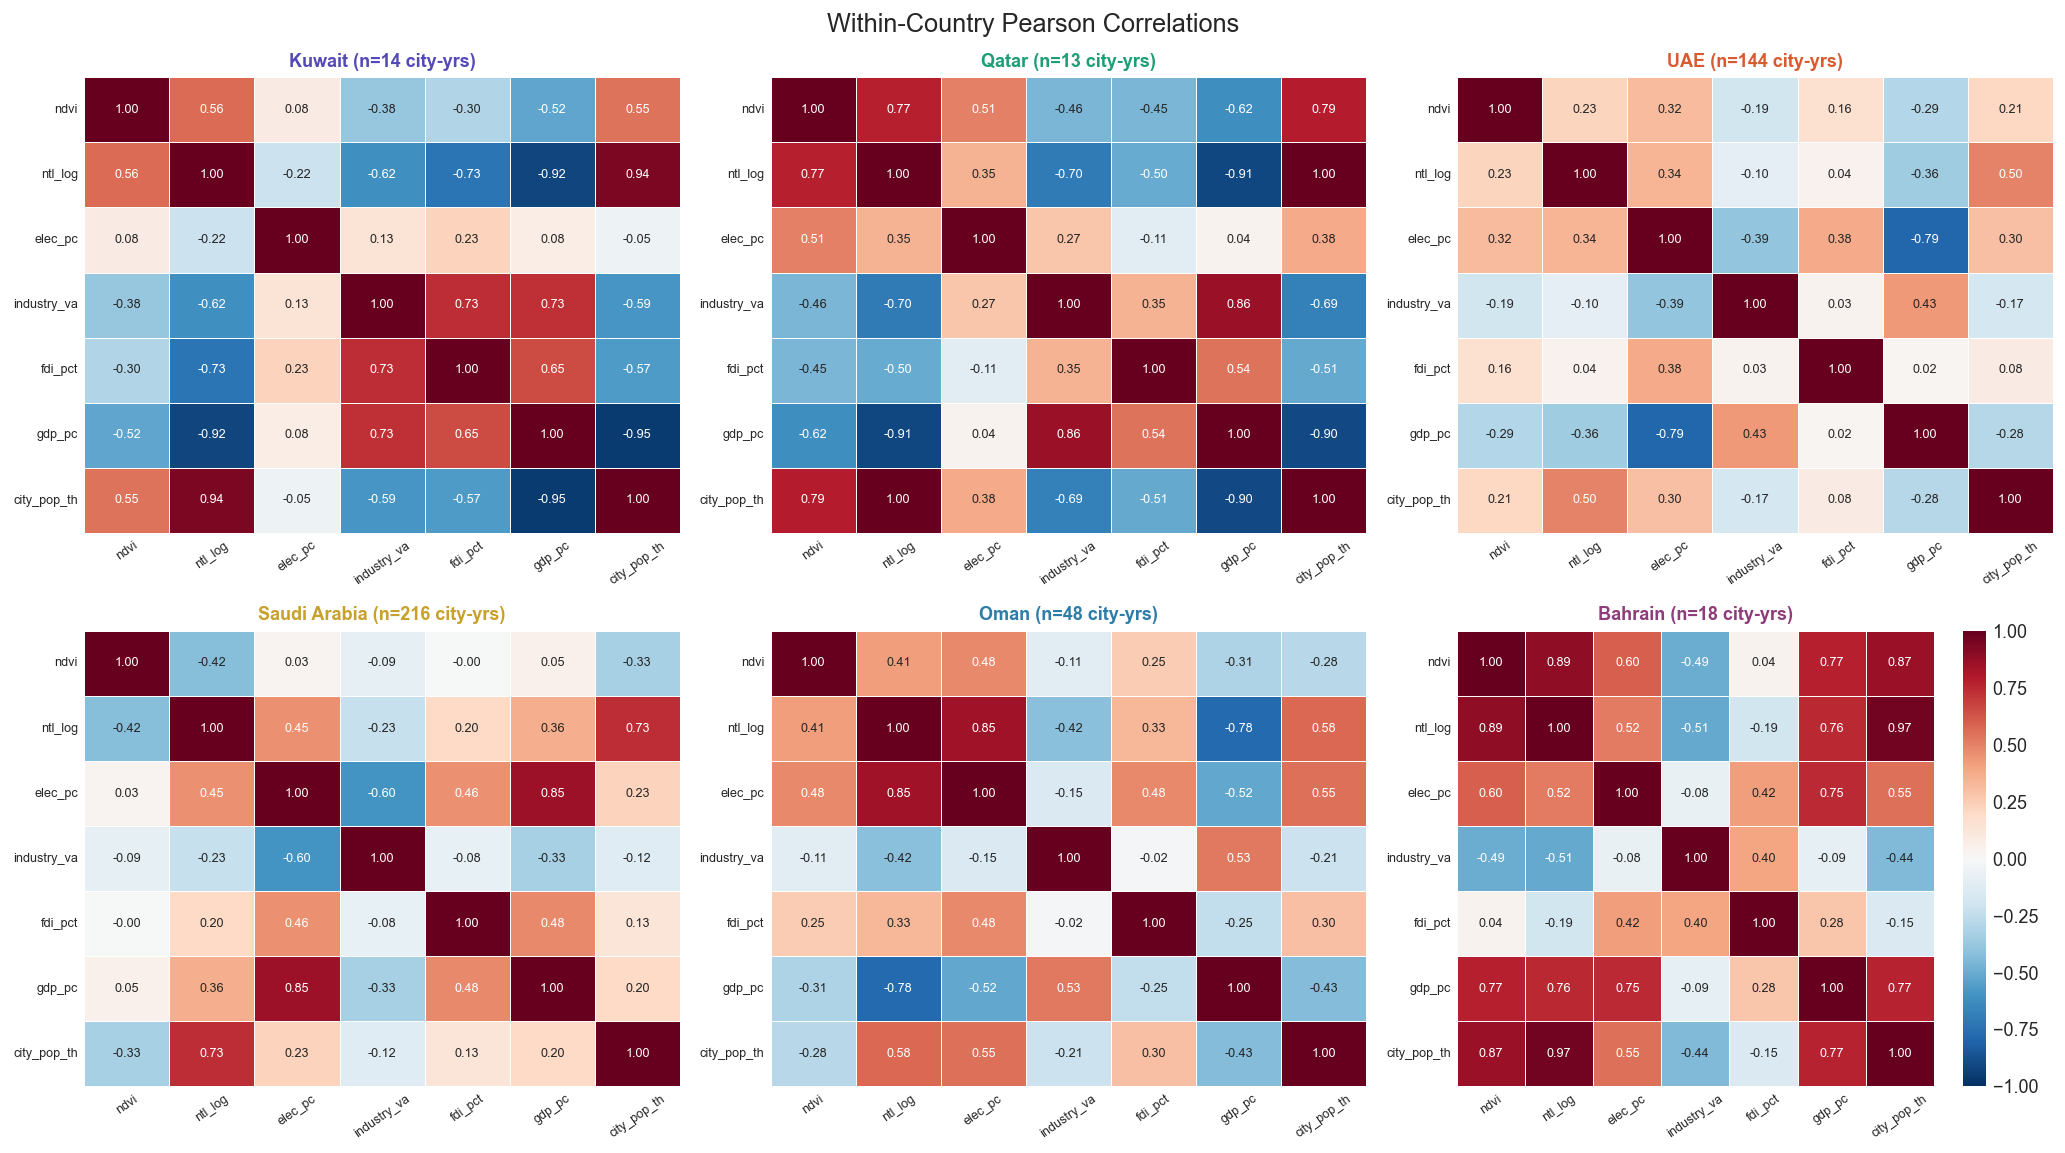

Saved: outputs/figures/s5a_corr_heatmaps.png


In [13]:

# §5a. Correlation heatmaps within each country (one matrix per country)
corr_cols = ['ndvi','ntl_log','elec_pc','industry_va','fdi_pct','gdp_pc','city_pop_th']
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, iso in zip(axes, order):
    sub = df[df['country']==iso][corr_cols].dropna()
    corr = sub.corr()
    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
    sns.heatmap(corr, ax=ax, annot=True, fmt='.2f', cmap='RdBu_r',
                center=0, vmin=-1, vmax=1,
                annot_kws={'size': 7}, linewidths=0.5,
                cbar=ax == axes[-1])
    ax.set_title(f'{COUNTRY_LABELS[iso]} (n={len(sub)} city-yrs)',
                 fontsize=10, color=COUNTRY_COLORS[iso], fontweight='bold')
    ax.tick_params(axis='x', labelsize=7, rotation=35)
    ax.tick_params(axis='y', labelsize=7, rotation=0)

fig.suptitle('Within-Country Pearson Correlations', fontsize=14)
savefig('s5a_corr_heatmaps.png')


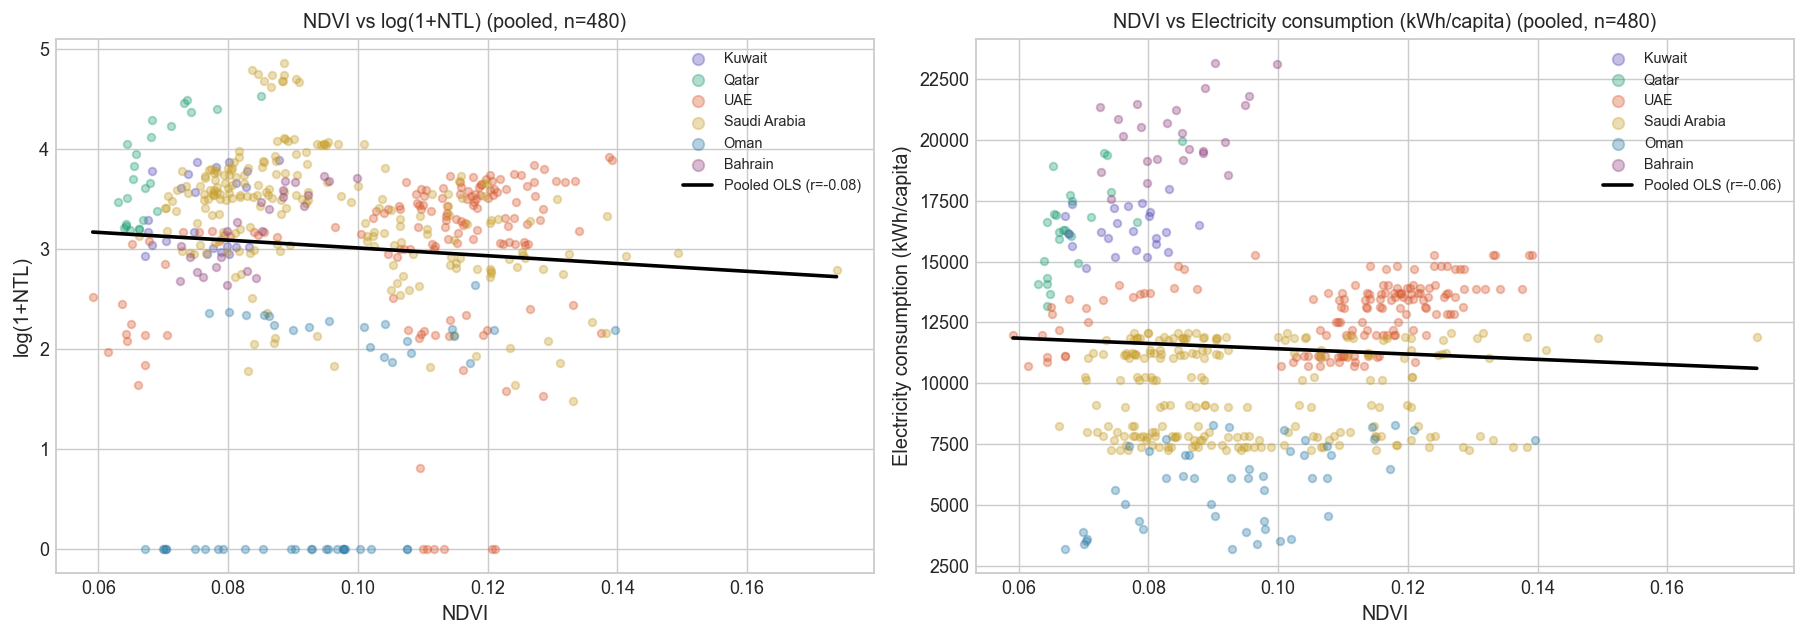

Saved: outputs/figures/s5bc_ndvi_scatters.png


In [14]:

# §5b & 5c. Pooled scatter: NDVI vs ntl_log and NDVI vs elec_pc
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (ycol, ylabel, filetag) in zip(axes, [
    ('ntl_log', 'log(1+NTL)', ''),
    ('elec_pc', 'Electricity consumption (kWh/capita)', ''),
]):
    for iso in order:
        s = df[df['country']==iso][[ycol,'ndvi']].dropna()
        ax.scatter(s['ndvi'], s[ycol],
                   color=COUNTRY_COLORS[iso], alpha=0.35, s=18,
                   label=COUNTRY_LABELS[iso])
    # Pooled OLS trend line
    pool = df[['ndvi', ycol]].dropna()
    slope, intercept, r, p, _ = stats.linregress(pool['ndvi'], pool[ycol])
    xr = np.linspace(pool['ndvi'].min(), pool['ndvi'].max(), 100)
    ax.plot(xr, intercept + slope*xr, 'k-', linewidth=2,
            label=f'Pooled OLS (r={r:.2f})')
    ax.set_xlabel('NDVI', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(f'NDVI vs {ylabel} (pooled, n={len(pool)})', fontsize=11)
    ax.legend(fontsize=8, loc='upper right', markerscale=1.5)

savefig('s5bc_ndvi_scatters.png')


## §6. Within-City Variation (Fixed-Effects Preview)

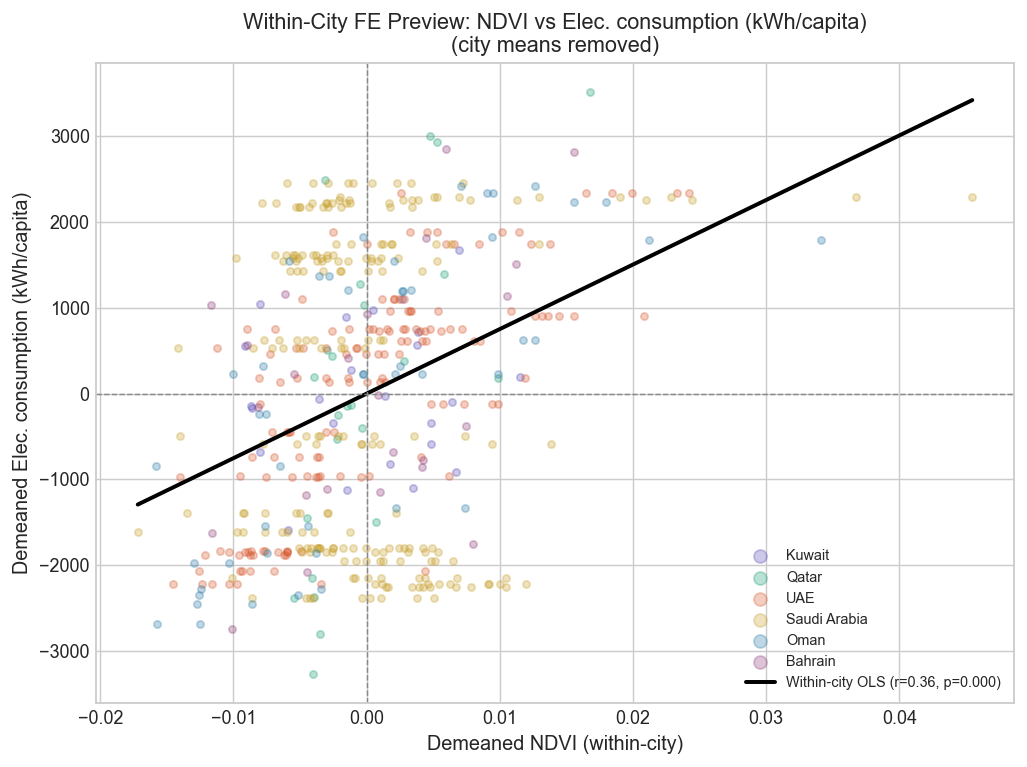

Saved: outputs/figures/s6a_fe_ndvi_elec.png
  Within-city r = 0.363, p = 0.0000, n = 480


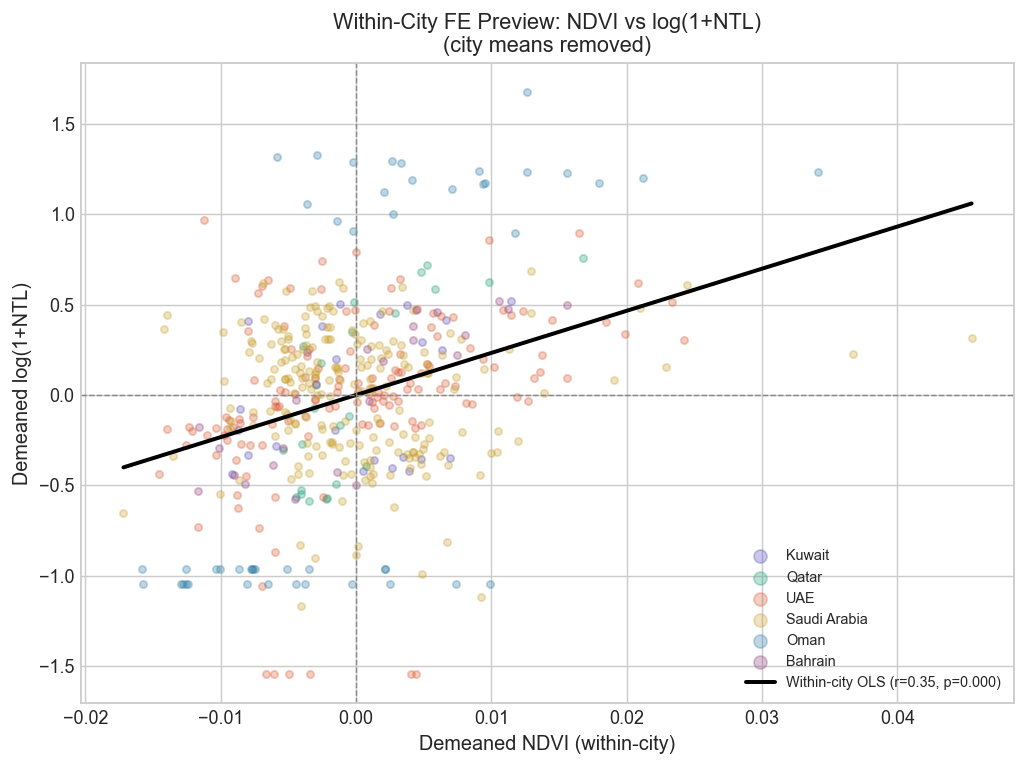

Saved: outputs/figures/s6b_fe_ndvi_ntl.png
  Within-city r = 0.347, p = 0.0000, n = 480


In [15]:

# §6. Demean by city mean — FE preview
fe_pairs = [
    ('ndvi', 'elec_pc',  'Elec. consumption (kWh/capita)', 's6a_fe_ndvi_elec.png'),
    ('ndvi', 'ntl_log',  'log(1+NTL)',                     's6b_fe_ndvi_ntl.png'),
]
for xcol, ycol, ylabel, fname in fe_pairs:
    sub = df[['city','country', xcol, ycol]].dropna().copy()
    sub['x_dm'] = sub[xcol] - sub.groupby('city')[xcol].transform('mean')
    sub['y_dm'] = sub[ycol] - sub.groupby('city')[ycol].transform('mean')

    slope, intercept, r, p, _ = stats.linregress(sub['x_dm'], sub['y_dm'])

    fig, ax = plt.subplots(figsize=(8, 6))
    for iso in order:
        s = sub[sub['country']==iso]
        ax.scatter(s['x_dm'], s['y_dm'],
                   color=COUNTRY_COLORS[iso], alpha=0.3, s=16,
                   label=COUNTRY_LABELS[iso])
    xr = np.linspace(sub['x_dm'].min(), sub['x_dm'].max(), 100)
    ax.plot(xr, intercept + slope*xr, 'k-', linewidth=2.2,
            label=f'Within-city OLS (r={r:.2f}, p={p:.3f})')
    ax.axhline(0, color='#888', linewidth=0.8, linestyle='--')
    ax.axvline(0, color='#888', linewidth=0.8, linestyle='--')
    ax.set_xlabel(f'Demeaned NDVI (within-city)', fontsize=11)
    ax.set_ylabel(f'Demeaned {ylabel}', fontsize=11)
    ax.set_title(f'Within-City FE Preview: NDVI vs {ylabel}\n(city means removed)',
                 fontsize=12)
    ax.legend(fontsize=8, markerscale=1.8)
    savefig(fname)
    print(f'  Within-city r = {r:.3f}, p = {p:.4f}, n = {len(sub)}')


## §7. Population Weighting

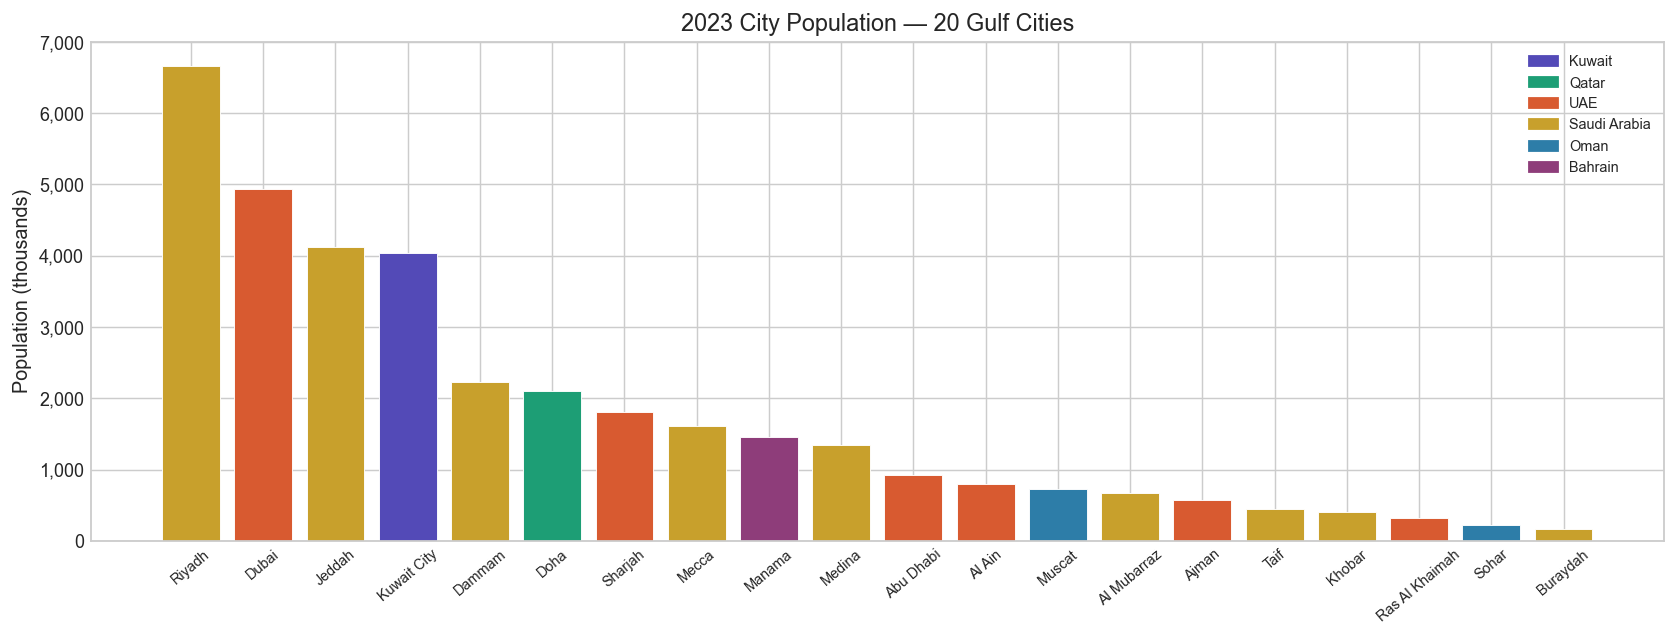

Saved: outputs/figures/s7a_population_bar.png


In [16]:

# §7a. Bar chart: 2023 city population, sorted descending
pop2023 = (df[df['year']==2023][['city','country','city_pop_th']]
             .sort_values('city_pop_th', ascending=False)
             .reset_index(drop=True))

fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.bar(pop2023['city'], pop2023['city_pop_th'],
              color=[COUNTRY_COLORS[iso] for iso in pop2023['country']],
              edgecolor='white', linewidth=0.5)
ax.set_ylabel('Population (thousands)', fontsize=11)
ax.set_title('2023 City Population — 20 Gulf Cities', fontsize=13)
ax.tick_params(axis='x', rotation=40, labelsize=8)
country_legend(ax, loc='upper right')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
savefig('s7a_population_bar.png')


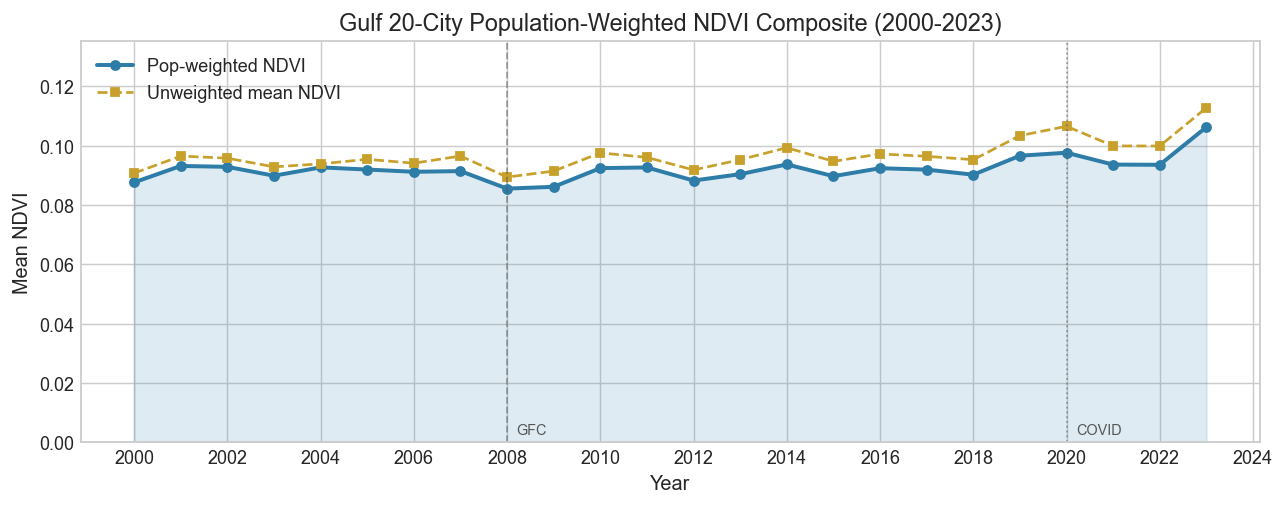

Saved: outputs/figures/s7b_ndvi_composite.png


In [17]:

# §7b. Pop-weighted NDVI composite (already computed in §2d, replot here standalone)
fig, ax = plt.subplots(figsize=(10, 4))
ax.fill_between(comp['year'], comp['ndvi_pop_weighted'],
                alpha=0.15, color='#2D7DA8')
ax.plot(comp['year'], comp['ndvi_pop_weighted'], 'o-', color='#2D7DA8',
        linewidth=2.2, markersize=5, label='Pop-weighted NDVI')
ax.plot(comp['year'], comp['ndvi_unweighted'], 's--', color='#C8A02C',
        linewidth=1.5, markersize=4, label='Unweighted mean NDVI')
ax.axvline(2008, color='#555', linestyle='--', linewidth=1, alpha=0.5)
ax.axvline(2020, color='#555', linestyle=':',  linewidth=1, alpha=0.5)
ax.text(2008.2, 0.003, 'GFC',   fontsize=8, color='#555')
ax.text(2020.2, 0.003, 'COVID', fontsize=8, color='#555')
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Mean NDVI', fontsize=11)
ax.set_title('Gulf 20-City Population-Weighted NDVI Composite (2000-2023)', fontsize=13)
ax.legend(fontsize=10)
ax.set_ylim(0, comp[['ndvi_pop_weighted','ndvi_unweighted']].max().max() * 1.2)
ax.xaxis.set_major_locator(mticker.MultipleLocator(2))
savefig('s7b_ndvi_composite.png')


## Summary

In [18]:

# Final summary
print("=" * 65)
print("EDA SUMMARY — Gulf NBS Panel")
print("=" * 65)

print(f"\nPanel: {len(df)} city-year obs | {df.city.nunique()} cities | "
      f"{df.year.nunique()} years ({df.year.min()}-{df.year.max()})")

print("\nCompleteness (city-years with data):")
key_vars = ['ndvi','ntl_calibrated','elec_pc','industry_va','fdi_pct',
            'gdp_pc','city_pop_th','env_exp_pct_gdp']
for v in key_vars:
    n = df[v].notna().sum()
    print(f"  {v:25s} {n:4d}/480 ({100*n/480:5.1f}%)")

print("\nKey anomalies / flags for regression:")
flags = [
    "NDVI: GEE vs Harvard cross-validation r — check §2c output",
    "NTL: Riyadh DMSP-era values underestimated (saturation at DN=63)",
    "NTL: Muscat/Sohar calibrated DMSP floored to 0 — use ntl_log",
    "NTL: Al Ain / Al Mubarraz / Buraydah show ~38-48% downward seam jump (DMSP bloom)",
    "industry_va: BHR 2000-05, KWT 2000-09, QAT 2000-10 are missing",
    "env_exp_pct_gdp: SAU entirely absent; others sparse — robustness use only",
    "Abu Dhabi city_pop: WUP shows decline 2010->2020 (boundary reclassification)",
    "Sohar city_pop: uses citypopulation.de admin boundary, not WUP city core",
]
for f in flags:
    print(f"  - {f}")

print("\nFigures saved to outputs/figures/:")
import glob, os
figs = sorted(glob.glob(FIG + 's*.png'))
for f in figs:
    print(f"  {os.path.basename(f)}")


EDA SUMMARY — Gulf NBS Panel

Panel: 480 city-year obs | 20 cities | 24 years (2000-2023)

Completeness (city-years with data):
  ndvi                       480/480 (100.0%)
  ntl_calibrated             480/480 (100.0%)
  elec_pc                    480/480 (100.0%)
  industry_va                453/480 ( 94.4%)
  fdi_pct                    480/480 (100.0%)
  gdp_pc                     480/480 (100.0%)
  city_pop_th                480/480 (100.0%)
  env_exp_pct_gdp            110/480 ( 22.9%)

Key anomalies / flags for regression:
  - NDVI: GEE vs Harvard cross-validation r — check §2c output
  - NTL: Riyadh DMSP-era values underestimated (saturation at DN=63)
  - NTL: Muscat/Sohar calibrated DMSP floored to 0 — use ntl_log
  - NTL: Al Ain / Al Mubarraz / Buraydah show ~38-48% downward seam jump (DMSP bloom)
  - industry_va: BHR 2000-05, KWT 2000-09, QAT 2000-10 are missing
  - env_exp_pct_gdp: SAU entirely absent; others sparse — robustness use only
  - Abu Dhabi city_pop: WUP shows dec

## §8. Summary Statistics

Final descriptive summary for the five key model variables: one independent variable (NDVI, measuring urban greenness) and four dependent variables (electricity per capita, industry value added, FDI net inflows, and nighttime lights). The pooled table covers all 480 city-year observations; the country-breakdown table groups by ISO3 to reveal cross-country heterogeneity.

In [19]:
# Pooled summary statistics across all 480 city-year observations
KEY_VARS = ['ndvi', 'elec_pc', 'industry_va', 'fdi_pct', 'ntl_calibrated']
VAR_LABELS = {
    'ndvi':           'NDVI',
    'elec_pc':        'Elec. (kWh/capita)',
    'industry_va':    'Industry VA (% GDP)',
    'fdi_pct':        'FDI (% GDP)',
    'ntl_calibrated': 'NTL (calibrated)',
}

raw_pooled = df[KEY_VARS].describe(percentiles=[0.25, 0.5, 0.75]).T
pooled = raw_pooled[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']].copy()
pooled.columns = ['N', 'Mean', 'SD', 'Min', 'p25', 'Median', 'p75', 'Max']
pooled['N'] = pooled['N'].astype(int)
pooled = pooled.round(2)
pooled.index = [VAR_LABELS[v] for v in KEY_VARS]
display(pooled)

,N,Mean,SD,Min,p25,Median,p75,Max
NDVI,480,0.10,0.02,0.06,0.08,0.09,0.11,0.17
Elec. (kWh/capita),480,11450.58,3772.27,3182.11,8007.94,11297.46,13672.12,23151.55
Industry VA (% GDP),453,52.65,7.59,38.20,45.96,52.83,57.90,74.81
FDI (% GDP),480,2.00,2.37,-2.76,0.24,1.40,2.89,15.75
NTL (calibrated),480,27.77,20.24,0.00,15.50,25.54,36.11,128.21


In [20]:
# Summary statistics broken out by country
country_order = ['KWT', 'QAT', 'ARE', 'SAU', 'OMN', 'BHR']
frames = []
for iso in country_order:
    sub = df[df['country'] == iso][KEY_VARS]
    raw_c = sub.describe(percentiles=[0.25, 0.5, 0.75]).T
    stats_c = raw_c[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']].copy()
    stats_c.columns = ['N', 'Mean', 'SD', 'Min', 'p25', 'Median', 'p75', 'Max']
    stats_c['N'] = stats_c['N'].astype(int)
    stats_c = stats_c.round(2)
    stats_c.index = [VAR_LABELS[v] for v in KEY_VARS]
    frames.append(stats_c)

country_stats = pd.concat(frames, keys=[COUNTRY_LABELS[iso] for iso in country_order])
country_stats.index.names = ['Country', 'Variable']
display(country_stats)

N      Mean       SD       Min       p25  \
Country      Variable                                                          
Kuwait       NDVI                  24      0.08     0.01      0.07      0.07   
             Elec. (kWh/capita)    24  16300.63   826.11  14716.77  15686.95   
             Industry VA (% GDP)   14     62.26     8.33     48.46     56.38   
             FDI (% GDP)           24      0.38     0.64     -0.50      0.01   
             NTL (calibrated)      24     30.09    11.53     17.76     19.52   
Qatar        NDVI                  24      0.07     0.01      0.06      0.06   
             Elec. (kWh/capita)    24  16451.71  1873.22  13180.07  14993.44   
             Industry VA (% GDP)   13     62.34     7.52     52.33     57.16   
             FDI (% GDP)           24      1.78     2.66     -1.69     -0.03   
             NTL (calibrated)      24     48.12    24.18     23.36     25.54   
UAE          NDVI                 144      0.11     0.02      0.06      0.11   
             Elec. (kWh/capita)   144  12947.02  1292.34  10724.54  11982.32   
             Industry VA (% GDP)  144     49.30     5.39     39.87     45.40   
             FDI (% GDP)          144      3.21     1.99     -0.49      2.16   
             NTL (calibrated)     144     23.80    12.03      0.00     17.92   
Saudi Arabia NDVI                 216      0.10     0.02      0.07      0.08   
             Elec. (kWh/capita)   216   9616.59  1812.31   7235.88   7801.73   
             Industry VA (% GDP)  216     53.50     7.45     38.30     47.19   
             FDI (% GDP)          216      0.81     1.00     -0.99      0.13   
             NTL (calibrated)     216     33.47    22.48      3.41     18.71   
Oman         NDVI                  48      0.09     0.02      0.07      0.08   
             Elec. (kWh/capita)    48   5864.21  1685.49   3182.11   4243.91   
             Industry VA (% GDP)   48     56.81     5.90     47.15     52.77   
             FDI (% GDP)           48      3.12     3.23     -2.76      1.16   
             NTL (calibrated)      48      3.72     4.24      0.00      0.00   
Bahrain      NDVI                  24      0.08     0.01      0.07      0.08   
             Elec. (kWh/capita)    24  20299.49  1477.65  17558.33  19184.02   
             Industry VA (% GDP)   18     43.77     3.44     38.20     40.83   
             FDI (% GDP)           24      4.94     4.20      0.20      2.31   
             NTL (calibrated)      24     25.69     9.97     12.99     15.70   

                                    Median       p75       Max  
Country      Variable                                           
Kuwait       NDVI                     0.08      0.08      0.09  
             Elec. (kWh/capita)   16216.38  16906.04  17971.16  
             Industry VA (% GDP)     60.21     69.43     74.81  
             FDI (% GDP)              0.18      0.51      2.12  
             NTL (calibrated)        24.47     41.94     48.00  
Qatar        NDVI                     0.07      0.07      0.09  
             Elec. (kWh/capita)   16475.10  17548.02  19963.24  
             Industry VA (% GDP)     59.98     69.76     73.47  
             FDI (% GDP)              0.64      3.40      8.31  
             NTL (calibrated)        38.81     69.05     92.42  
UAE          NDVI                     0.11      0.12      0.14  
             Elec. (kWh/capita)   13271.76  13742.98  15284.70  
             Industry VA (% GDP)     49.50     53.45     58.02  
             FDI (% GDP)              2.59      5.04      6.77  
             NTL (calibrated)        24.21     33.23     49.40  
Saudi Arabia NDVI                     0.09      0.11      0.17  
             Elec. (kWh/capita)    9632.76  11265.69  12074.53  
             Industry VA (% GDP)     53.71     59.66     66.43  
             FDI (% GDP)              0.62      1.40      3.19  
             NTL (calibrated)        31.76     40.50    128.21  
Oman         NDVI                     0.10   

The UAE records the highest mean NDVI (0.11) across the six countries — reflecting sustained urban greening in Dubai and Abu Dhabi — while Qatar (0.07) and Kuwait (0.08) sit at the lower end, consistent with more arid, high-density urban cores. Electricity consumption per capita varies dramatically: Bahrain's mean of ~20,300 kWh/capita is more than 3.4× Oman's (~5,900 kWh), a gap that strongly motivates country fixed effects in the regression. FDI net inflows show the highest coefficient of variation of any variable in the table (SD ≈ 1.2× the mean), with values ranging from negative (capital reversals) to over 15 % of GDP, which supports the use of cluster-robust standard errors.

In [21]:
# Save summary tables to outputs/tables/
TBL = FIG.replace('/figures/', '/tables/')
os.makedirs(TBL, exist_ok=True)

pooled_save = pooled.copy()
pooled_save.index.name = 'Variable'
pooled_save.to_csv(TBL + 'summary_stats_pooled.csv')

country_stats.to_csv(TBL + 'summary_stats_by_country.csv')

print(f'Saved: {TBL}summary_stats_pooled.csv')
print(f'Saved: {TBL}summary_stats_by_country.csv')

Saved: outputs/tables/summary_stats_pooled.csv
Saved: outputs/tables/summary_stats_by_country.csv
